# Random-Matrix Benchmark — CPU vs FPGA Accelerator
Random images and random 3×3 kernels are generated on the fly. Two test sweeps are run:

1. **Test A** — width fixed at 16, height varies 16 → 1000
2. **Test B** — width fixed at 60, height varies 16 → 1000

Both tests use **20,000 random images** each, with a fresh random 3×3 kernel per image. Only timing is measured — no CPU utilization, no file I/O. This isolates pure compute time.

In [1]:
# Loading imports
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from pynq import Overlay, allocate

print("Imports completed")

Imports completed


In [2]:
# ── Test configuration ──────────────────────────────────────────────────
N_IMAGES       = 20_000      # images per test
HEIGHT_MIN     = 16
HEIGHT_MAX     = 1000

FPGA_MAX_W     = 60
FPGA_MAX_H     = 1020
BITSTREAM_PATH = 'conv100m.bit'

RNG = np.random.default_rng(seed=42)

print(f"Test A: width=16,  height in [{HEIGHT_MIN}, {HEIGHT_MAX}],  N={N_IMAGES:,}")
print(f"Test B: width=60,  height in [{HEIGHT_MIN}, {HEIGHT_MAX}],  N={N_IMAGES:,}")

Test A: width=16,  height in [16, 1000],  N=20,000
Test B: width=60,  height in [16, 1000],  N=20,000


## One-time FPGA setup

In [3]:
# ── Overlay, DMA, CMA buffers (allocated once for both tests) ──────────
ol  = Overlay(BITSTREAM_PATH)
dma = ol.axi_dma

def _to_s9(v):
    v = max(-256, min(255, int(v)))
    return v & 0x1FF

def _pack_kernel_words(k):
    """Returns (kw0, kw1, kw2) — three packed config words for a 3x3 kernel."""
    def pack_row(r):
        return _to_s9(k[r][0]) | (_to_s9(k[r][1]) << 9) | (_to_s9(k[r][2]) << 18)
    return pack_row(0), pack_row(1), pack_row(2)

# Worst-case CMA buffer sizes
_max_px  = FPGA_MAX_W * FPGA_MAX_H
_max_in  = 4 + (_max_px + 3) // 4
_max_out = ((FPGA_MAX_W - 2) * (FPGA_MAX_H - 2) + 3) // 4 + 8

send_buf   = allocate(shape=(_max_in,),  dtype=np.uint32)
recv_buf   = allocate(shape=(_max_out,), dtype=np.uint32)
send_bytes = send_buf.view(np.uint8)[16:]   # pixel region (after 4 config words)

dma.sendchannel.stop();  dma.recvchannel.stop()
dma.sendchannel.start(); dma.recvchannel.start()

# Cache attribute lookups
_send_xfer = dma.sendchannel.transfer
_recv_xfer = dma.recvchannel.transfer
_send_wait = dma.sendchannel.wait
_recv_wait = dma.recvchannel.wait

print("FPGA ready. Buffers allocated:",
      f"send={_max_in*4} bytes, recv={_max_out*4} bytes")

FPGA ready. Buffers allocated: send=61216 bytes, recv=59076 bytes


## Test runner — generates images and times CPU + FPGA

In [4]:
# ── Reusable benchmark function ────────────────────────────────────────
def run_benchmark(width, n_images, h_min, h_max, label):
    """
    Generate n_images random images of (random_height x width) with a random
    3x3 kernel each, then time scipy convolve2d and the FPGA accelerator.
    Returns (cpu_times, fpga_times, heights).
    """
    print(f"\n[{label}] Generating {n_images:,} random images "
          f"({width} wide, height {h_min}..{h_max})...")

    # Pre-generate everything so the timing loop only measures compute
    heights = RNG.integers(h_min, h_max + 1, size=n_images, dtype=np.int32)
    images  = [RNG.integers(0, 256, (int(h), width), dtype=np.uint8) for h in heights]
    kernels = [RNG.integers(-4, 5, (3, 3), dtype=np.int32) for _ in range(n_images)]

    cpu_times  = np.empty(n_images, dtype=np.float64)
    fpga_times = np.empty(n_images, dtype=np.float64)

    # ── CPU pass ───────────────────────────────────────────────────────
    print(f"[{label}] CPU pass...")
    t_start = time.perf_counter()
    for i in range(n_images):
        img, k = images[i], kernels[i]
        t0 = time.perf_counter()
        _ = convolve2d(img, k, mode='valid')
        t1 = time.perf_counter()
        cpu_times[i] = t1 - t0
        if (i + 1) % 5000 == 0:
            print(f"  CPU  {i+1:,}/{n_images:,}")
    cpu_total = time.perf_counter() - t_start
    print(f"[{label}] CPU done in {cpu_total:.2f}s")

    # ── FPGA pass ──────────────────────────────────────────────────────
    print(f"[{label}] FPGA pass...")
    prev_h = -1                        # force config rewrite on first iteration
    s_sl = r_sl = None                 # current send/recv slices

    t_start = time.perf_counter()
    for i in range(n_images):
        img = images[i]
        k   = kernels[i]
        h   = int(heights[i])
        n_px = h * width

        # Pack the kernel for this image
        kw0, kw1, kw2 = _pack_kernel_words(k)

        # Update config words and slices when height changes (or first iter)
        if h != prev_h:
            send_buf[0] = (width & 0x3F) | ((h & 0x3FF) << 6)
            n_words_in  = 4 + (n_px + 3) // 4
            n_out_words = ((h - 2) * (width - 2) + 3) // 4
            s_sl = send_buf[:n_words_in]
            r_sl = recv_buf[:n_out_words]
            prev_h = h
        # Kernel changes every image, so always rewrite kernel words
        send_buf[1] = kw0
        send_buf[2] = kw1
        send_buf[3] = kw2

        # Zero-copy pixel write
        send_bytes[:n_px] = img.ravel()
        rem = n_px % 4
        if rem:
            send_bytes[n_px:n_px + (4 - rem)] = 0

        t0 = time.perf_counter()
        _recv_xfer(r_sl)
        _send_xfer(s_sl)
        _send_wait()
        _recv_wait()
        t1 = time.perf_counter()
        fpga_times[i] = t1 - t0

        if (i + 1) % 5000 == 0:
            print(f"  FPGA {i+1:,}/{n_images:,}")
    fpga_total = time.perf_counter() - t_start
    print(f"[{label}] FPGA done in {fpga_total:.2f}s")

    return cpu_times, fpga_times, heights

## Test A — width 16, height 16 → 1000

In [5]:
cpu_a, fpga_a, heights_a = run_benchmark(
    width=16, n_images=N_IMAGES,
    h_min=HEIGHT_MIN, h_max=HEIGHT_MAX,
    label='Test A (W=16)'
)

print(f"\nTest A summary:")
print(f"  CPU  avg : {cpu_a.mean()*1000:8.3f} ms   total: {cpu_a.sum():.2f}s")
print(f"  FPGA avg : {fpga_a.mean()*1000:8.3f} ms   total: {fpga_a.sum():.2f}s")
print(f"  Speedup  : {cpu_a.mean()/fpga_a.mean():.2f}x")


[Test A (W=16)] Generating 20,000 random images (16 wide, height 16..1000)...
[Test A (W=16)] CPU pass...
  CPU  5,000/20,000
  CPU  10,000/20,000
  CPU  15,000/20,000
  CPU  20,000/20,000
[Test A (W=16)] CPU done in 118.72s
[Test A (W=16)] FPGA pass...
  FPGA 5,000/20,000
  FPGA 10,000/20,000
  FPGA 15,000/20,000
  FPGA 20,000/20,000
[Test A (W=16)] FPGA done in 27.29s

Test A summary:
  CPU  avg :    5.913 ms   total: 118.25s
  FPGA avg :    0.820 ms   total: 16.40s
  Speedup  : 7.21x


## Test B — width 60, height 16 → 1000

In [6]:
cpu_b, fpga_b, heights_b = run_benchmark(
    width=60, n_images=N_IMAGES,
    h_min=HEIGHT_MIN, h_max=HEIGHT_MAX,
    label='Test B (W=60)'
)

print(f"\nTest B summary:")
print(f"  CPU  avg : {cpu_b.mean()*1000:8.3f} ms   total: {cpu_b.sum():.2f}s")
print(f"  FPGA avg : {fpga_b.mean()*1000:8.3f} ms   total: {fpga_b.sum():.2f}s")
print(f"  Speedup  : {cpu_b.mean()/fpga_b.mean():.2f}x")


[Test B (W=60)] Generating 20,000 random images (60 wide, height 16..1000)...
[Test B (W=60)] CPU pass...
  CPU  5,000/20,000
  CPU  10,000/20,000
  CPU  15,000/20,000
  CPU  20,000/20,000
[Test B (W=60)] CPU done in 596.00s
[Test B (W=60)] FPGA pass...
  FPGA 5,000/20,000
  FPGA 10,000/20,000
  FPGA 15,000/20,000
  FPGA 20,000/20,000
[Test B (W=60)] FPGA done in 116.80s

Test B summary:
  CPU  avg :   29.730 ms   total: 594.61s
  FPGA avg :    1.116 ms   total: 22.33s
  Speedup  : 26.63x


## Timing analysis

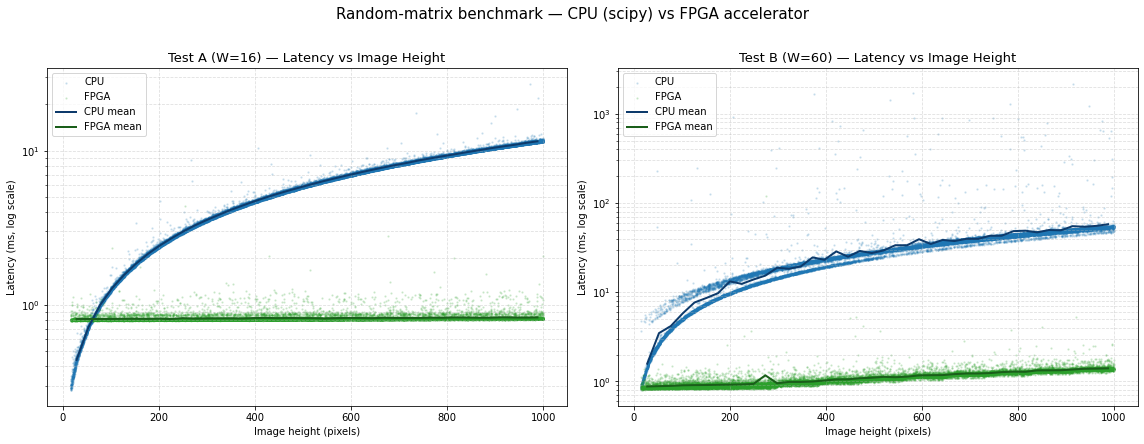

In [7]:
# ── 2-panel comparison: latency-vs-height (log scale) ──────────────────
def bin_by_height(times_ms, heights, n_bins=40):
    """Average latency within each height bin (smoother trend curve)."""
    bins = np.linspace(heights.min(), heights.max(), n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    means = np.full(n_bins, np.nan)
    for b in range(n_bins):
        mask = (heights >= bins[b]) & (heights < bins[b+1])
        if mask.any():
            means[b] = times_ms[mask].mean()
    return centers, means

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Test A ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(heights_a, cpu_a*1000,  s=2, alpha=0.15, color='#1f77b4', label='CPU')
ax.scatter(heights_a, fpga_a*1000, s=2, alpha=0.15, color='#2ca02c', label='FPGA')
hc, mc = bin_by_height(cpu_a*1000,  heights_a)
hf, mf = bin_by_height(fpga_a*1000, heights_a)
ax.plot(hc, mc, color='#0d3a6b', linewidth=2, label='CPU mean')
ax.plot(hf, mf, color='#1a5e1a', linewidth=2, label='FPGA mean')
ax.set_yscale('log')
ax.set_title('Test A (W=16) — Latency vs Image Height', fontsize=13)
ax.set_xlabel('Image height (pixels)')
ax.set_ylabel('Latency (ms, log scale)')
ax.legend(loc='upper left')
ax.grid(True, ls='--', alpha=0.4, which='both')

# ── Test B ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(heights_b, cpu_b*1000,  s=2, alpha=0.15, color='#1f77b4', label='CPU')
ax.scatter(heights_b, fpga_b*1000, s=2, alpha=0.15, color='#2ca02c', label='FPGA')
hc, mc = bin_by_height(cpu_b*1000,  heights_b)
hf, mf = bin_by_height(fpga_b*1000, heights_b)
ax.plot(hc, mc, color='#0d3a6b', linewidth=2, label='CPU mean')
ax.plot(hf, mf, color='#1a5e1a', linewidth=2, label='FPGA mean')
ax.set_yscale('log')
ax.set_title('Test B (W=60) — Latency vs Image Height', fontsize=13)
ax.set_xlabel('Image height (pixels)')
ax.set_ylabel('Latency (ms, log scale)')
ax.legend(loc='upper left')
ax.grid(True, ls='--', alpha=0.4, which='both')

plt.suptitle('Random-matrix benchmark — CPU (scipy) vs FPGA accelerator',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('random_matrix_benchmark.png', facecolor='white', bbox_inches='tight')
plt.show()

## Results — Side-by-Side Comparison

In [8]:
# ── Summary statistics ──────────────────────────────────────────────────
def stats(t):
    t_ms = t * 1000
    return t_ms.mean(), t_ms.min(), t_ms.max()

print("=" * 70)
print(f"{'Metric':<20} {'CPU A (W=16)':>14} {'FPGA A':>10} "
      f"{'CPU B (W=60)':>14} {'FPGA B':>10}")
print("-" * 70)

cA = stats(cpu_a);  fA = stats(fpga_a)
cB = stats(cpu_b);  fB = stats(fpga_b)

labels = ['Mean (ms)', 'Min  (ms)', 'Max  (ms)']
for i, lab in enumerate(labels):
    print(f"{lab:<20} {cA[i]:>14.3f} {fA[i]:>10.3f} "
          f"{cB[i]:>14.3f} {fB[i]:>10.3f}")

print("-" * 70)
print(f"{'Speedup CPU/FPGA':<20} "
      f"{'':>14} {cA[0]/fA[0]:>9.2f}x "
      f"{'':>14} {cB[0]/fB[0]:>9.2f}x")
print("=" * 70)

Metric                 CPU A (W=16)     FPGA A   CPU B (W=60)     FPGA B
----------------------------------------------------------------------
Mean (ms)                     5.913      0.820         29.730      1.116
Min  (ms)                     0.279      0.785          0.792      0.806
Max  (ms)                    27.226      4.367       2183.722    120.546
----------------------------------------------------------------------
Speedup CPU/FPGA                         7.21x                    26.63x


In [9]:
# ── Free CMA buffers ───────────────────────────────────────────────────
try:
    send_buf.freebuffer()
    recv_buf.freebuffer()
    print("Buffers freed.")
except Exception as e:
    print(f"Cleanup: {e}")

Buffers freed.
